In [ ]:
from google.colab import files
uploaded = files.upload()


Saving continuous dataset.csv to continuous dataset (1).csv


In [ ]:
import os
os.listdir()


['.config',
 'continuous dataset.csv',
 'continuous dataset (1).csv',
 'sample_data']

In [ ]:
import os

os.rename("continuous dataset.csv", "continuous_dataset.csv")


In [ ]:
os.listdir()


['.config',
 'continuous_dataset.csv',
 'continuous dataset (1).csv',
 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("continuous_dataset.csv")
df.head()


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [ ]:
df.columns


Index(['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
       'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav',
       'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school'],
      dtype='object')

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')
df.tail()


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
48043,2020-06-26 20:00:00,1128.5592,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,23.746545,0.018381,0.150879,2.444658,0,0,1
48044,2020-06-26 21:00:00,1112.7488,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,23.693323,0.018320,0.156311,2.515814,0,0,1
48045,2020-06-26 22:00:00,1081.5680,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,23.658655,0.018327,0.153259,2.800717,0,0,1
48046,2020-06-26 23:00:00,1041.6240,26.867487,0.020464,0.064178,10.326567,25.258112,0.019403,0.108063,2.720871,23.601862,0.018358,0.152771,3.138132,0,0,1
48047,2020-06-27 00:00:00,1013.5683,26.750330,0.020441,0.063965,10.198346,25.125330,0.019281,0.100189,2.785751,23.562830,0.018404,0.162598,3.286878,0,0,1


In [ ]:
import numpy as np

target = "nat_demand"
data = df[target].values.reshape(-1, 1)

print(data.shape)


(48048, 1)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])


[[0.53013   ]
 [0.49529149]
 [0.4881604 ]
 [0.48198261]
 [0.48421817]]


In [ ]:
def create_sequences(data, steps=24):
    X, y = [], []
    for i in range(steps, len(data)):
        X.append(data[i-steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, steps=24)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (48024, 24)
y shape: (48024,)


In [ ]:
# 14 days = 14 × 24 hours
test_size = 14 * 24

X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (47688, 24)
Testing samples: (336, 24)


In [ ]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print("Reshaped X_train:", X_train.shape)
print("Reshaped X_test :", X_test.shape)


Reshaped X_train: (47688, 24, 1)
Reshaped X_test : (336, 24, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, input_shape=(24, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)


Epoch 1/15
746/746 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0317 - val_loss: 0.0014
Epoch 2/15
746/746 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0016 - val_loss: 8.2209e-04
Epoch 3/15
746/746 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 9.6407e-04 - val_loss: 7.1891e-04
Epoch 4/15
746/746 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 7.2587e-04 - val_loss: 6.5489e-04
Epoch 5/15
746/746 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 6.8995e-04 - val_loss: 5.3903e-04
Epoch 6/15
746/746 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5.9467e-04 - val_loss: 4.5524e-04
Epoch 7/15
746/746 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 5.4280e-04 - val_loss: 5.7652e-04
Epoch 8/15
746/746 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5.6847e-04 - val_loss: 4.3669e-04
Epoch 9/15
746/746 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5.4400e-04 - val_loss: 4.5064e-04
Epoch 10/15
746/746 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5.2283e-04 - val_loss: 5.9411e-04
Epoch 11/15
746/746 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/st

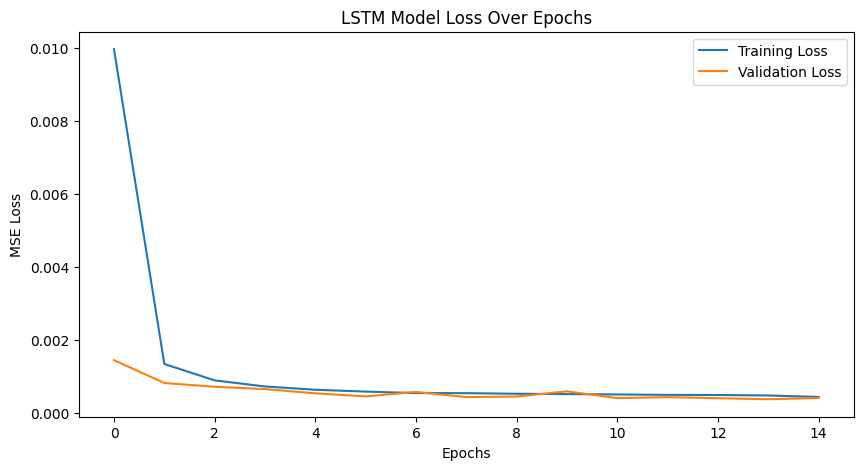

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


In [ ]:
# Predict on test set
y_pred = model.predict(X_test)

# Optional: reshape if needed (depends on your data)
y_pred = y_pred.flatten()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


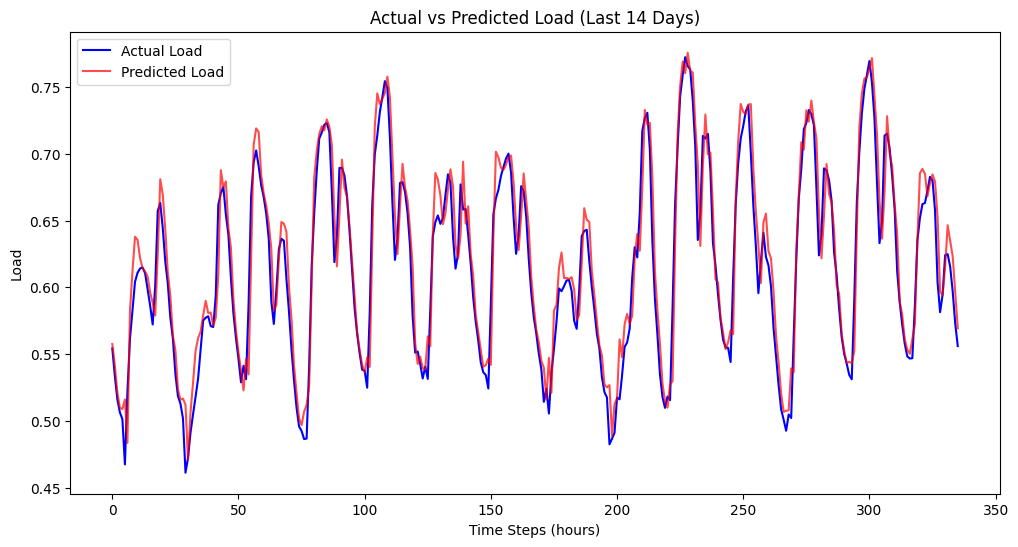

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual Load', color='blue')
plt.plot(y_pred, label='Predicted Load', color='red', alpha=0.7)
plt.title('Actual vs Predicted Load (Last 14 Days)')
plt.xlabel('Time Steps (hours)')
plt.ylabel('Load')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE  : {mse:.3f}")
print(f"Test RMSE : {rmse:.3f}")
print(f"Test MAE  : {mae:.3f}")
print(f"R2 Score  : {r2:.3f}")


Test MSE  : 0.000
Test RMSE : 0.020
Test MAE  : 0.016
R2 Score  : 0.919
